# 🏢 OFFICE CATEGORY PREDICTION - BASELINE TEMPLATE

This notebook provides a simple baseline for the Office Classification challenge.

**Your task:** Improve upon this baseline by trying different approaches!

## 💡 Hints on What to Try

1. **Feature Engineering** - Create interactions, polynomials, ratios
2. **Different Models** - Random Forest, XGBoost, Neural Networks
3. **Hyperparameter Tuning** - Optimize model parameters
4. **Ensemble Methods** - Combine multiple models
5. **Handle Missing Values Better** - Try different imputation strategies
6. **Encode Categoricals Differently** - One-hot encoding, target encoding


**Good luck!** 🚀

In [6]:
# ============================================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')


In [7]:
train = pd.read_csv("office_train.csv")
test  = pd.read_csv("office_test.csv")

In [8]:
# ============================================================================
# STEP 2: LOAD DATA
# ============================================================================

# Load training data
train = pd.read_csv('office_train.csv')

# Separate features and target
X = train.drop('OfficeCategory', axis=1)
y = train['OfficeCategory']

print("Dataset loaded successfully!")
print(f"Shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts().sort_index()}")

# TODO: Explore the data here
# - Check for missing values: X.isnull().sum()
# - Look at feature distributions: X.describe()
# - Visualize relationships: Use matplotlib/seaborn
# - Understand which features matter most

Dataset loaded successfully!
Shape: (35000, 79)
Target distribution:
OfficeCategory
0    6675
1    7314
2    6906
3    7013
4    7092
Name: count, dtype: int64


In [28]:
# ============================================================================
# STEP 3: SIMPLE PREPROCESSING
# ============================================================================

import numpy as np

def simple_preprocess(X_train, X_test=None):
    """
    Basic preprocessing:
    - Median imputation for numeric features
    - Mode imputation + label encoding for categoricals
    """

    # Make copies
    X_train = X_train.copy()
    if X_test is not None:
        X_test = X_test.copy()

    # Identify feature types
    numeric_features = X_train.select_dtypes(include=[np.number]).columns
    categorical_features = X_train.select_dtypes(include=['object']).columns

    print(f"Numeric features: {len(numeric_features)}")
    print(f"Categorical features: {len(categorical_features)}")

    # Fill missing values - NUMERIC (median)
    for col in numeric_features:
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
        if X_test is not None:
            X_test[col] = X_test[col].fillna(median_val)

    # Fill missing values and label encode categoricals
    for col in categorical_features:
        mode_val = X_train[col].mode()[0] if len(X_train[col].mode()) > 0 else 'Missing'
        X_train[col] = X_train[col].fillna(mode_val).astype(str)
        if X_test is not None:
            X_test[col] = X_test[col].fillna(mode_val).astype(str)
        le = LabelEncoder()
        if X_test is not None:
            combined = pd.concat([X_train[col], X_test[col]], axis=0)
            le.fit(combined)
            X_train[col] = le.transform(X_train[col])
            X_test[col] = le.transform(X_test[col])
        else:
            X_train[col] = le.fit_transform(X_train[col])

    # Final safety check
    X_train = X_train.fillna(0)
    if X_test is not None:
        X_test = X_test.fillna(0)
        return X_train, X_test
    return X_train

# Apply preprocessing
X_processed = simple_preprocess(X)

print(f"After preprocessing:")
print(f"Shape: {X_processed.shape}")
print(f"Missing values: {X_processed.isnull().sum().sum()}")


Numeric features: 37
Categorical features: 42
After preprocessing:
Shape: (35000, 79)
Missing values: 0


### How categorical features are encoded
1. **Identify categorical columns:** `categorical_features = X_train.select_dtypes(include=['object']).columns` captures every non-numeric field.
2. **Impute missing labels:** For each categorical column, the mode is computed on the training split; missing entries are filled with that mode (fallback `'Missing'` when no mode exists) to avoid NaN tokens.
3. **Fit a per-column label encoder:** `LabelEncoder` is fit on the combined train+test values when a test frame is provided, so both splits share the same integer vocabulary; otherwise it fits on training values only. All labels are cast to string before fitting to guarantee consistency.
4. **Transform to integers:** The encoder converts each categorical column to contiguous integer IDs, producing a dense numerical matrix consumable by tree/linear models.
5. **Final NaN guard:** After encoding, a final fill of remaining nulls with zero ensures models never see missing tokens at fit or predict time.


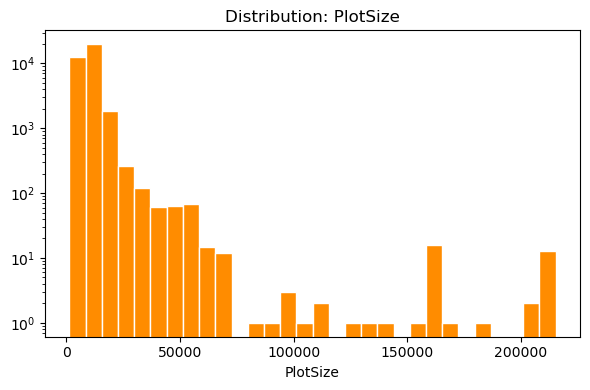

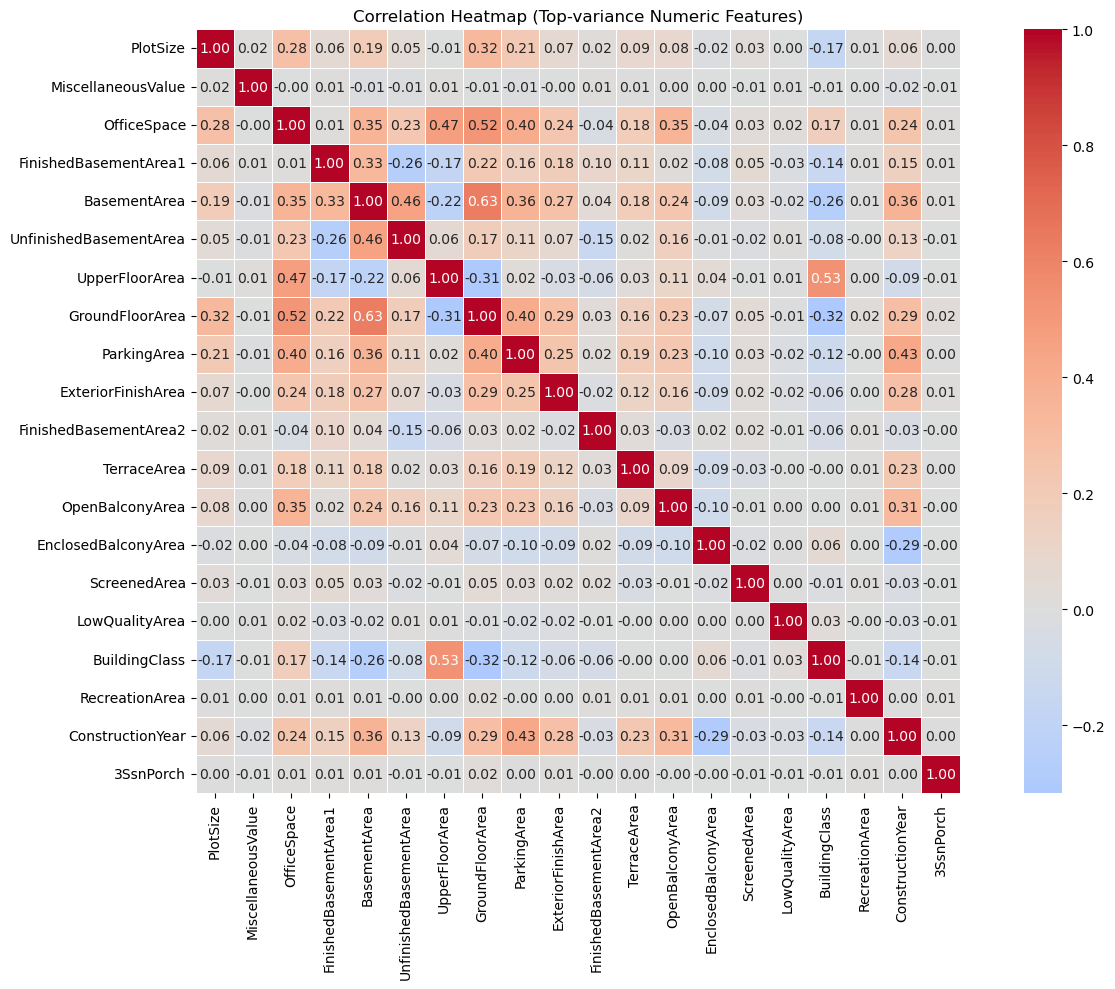

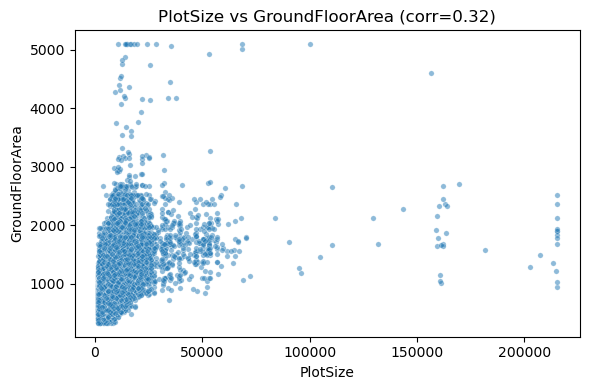

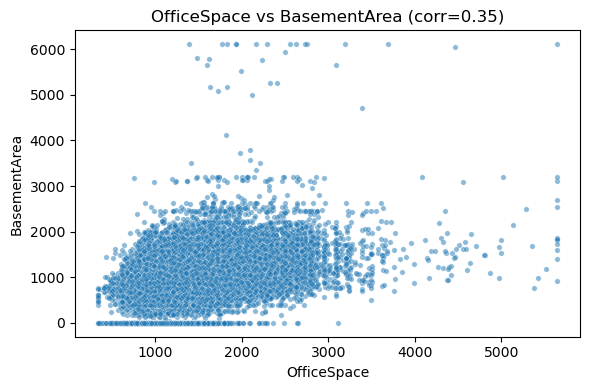

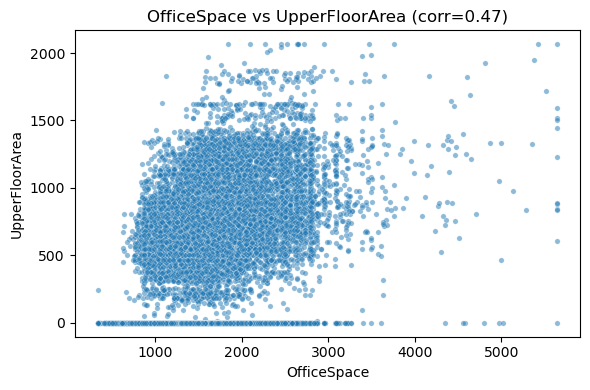

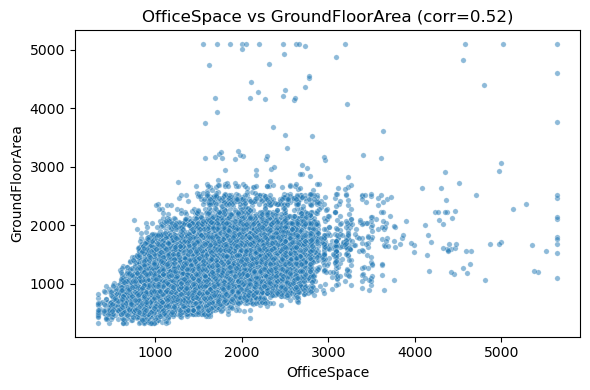

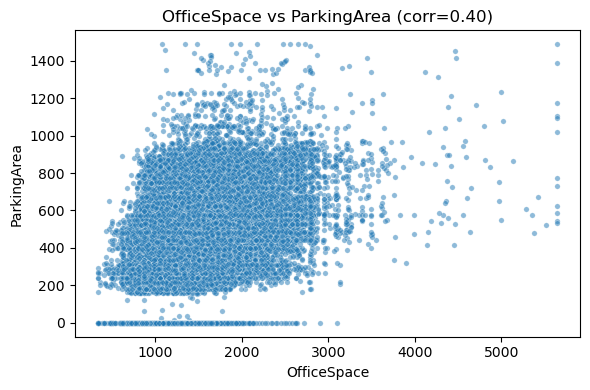

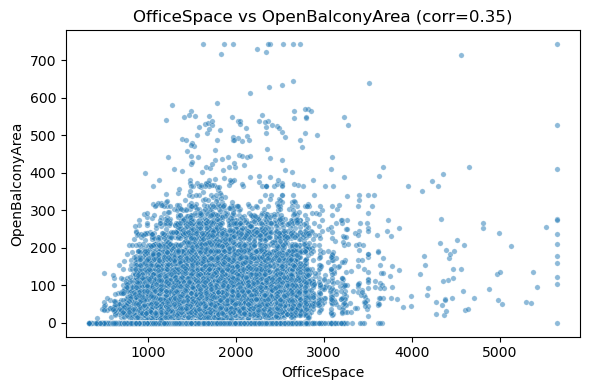

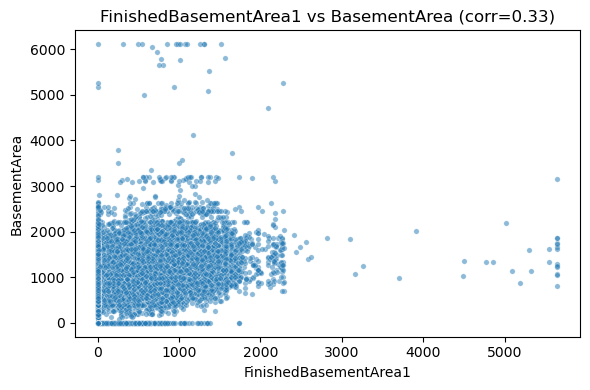

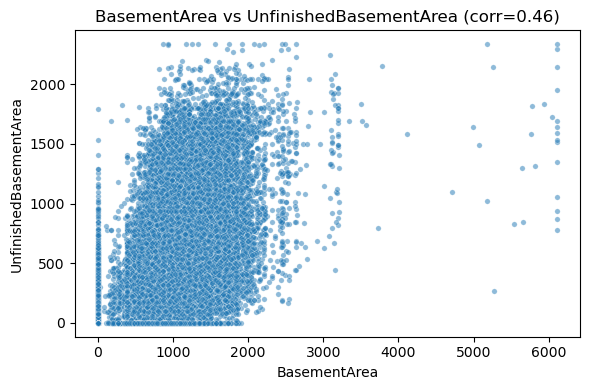

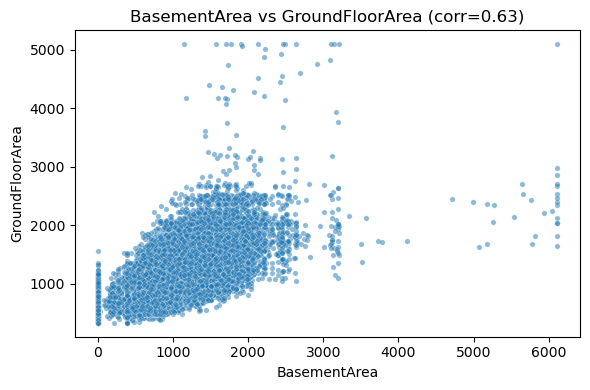

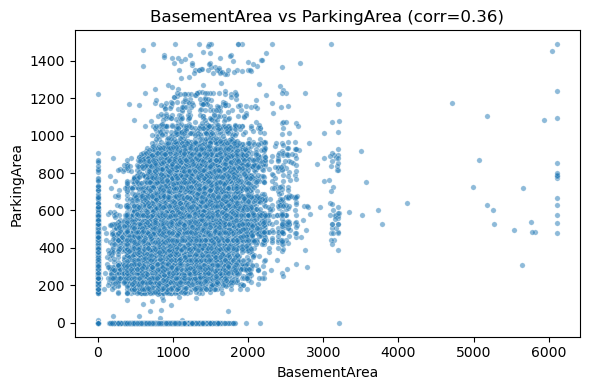

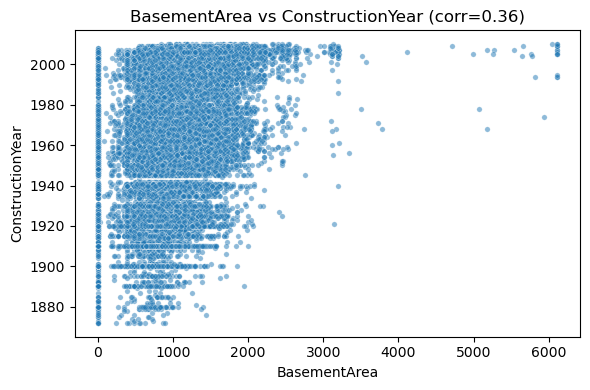

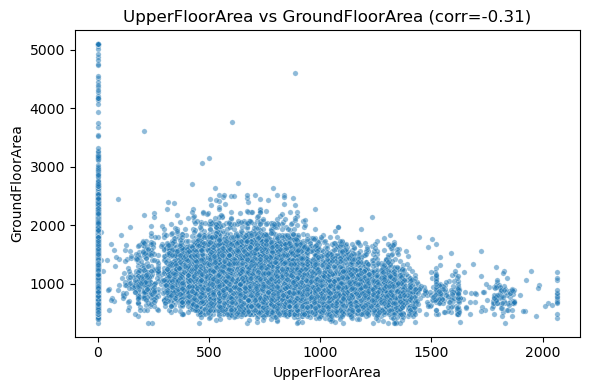

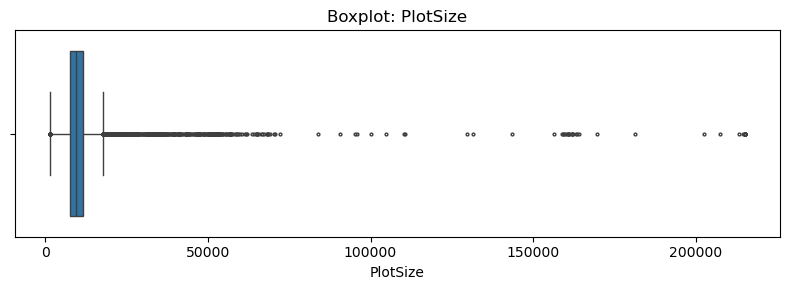

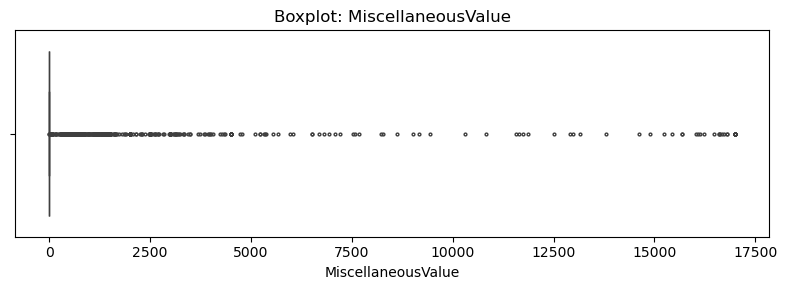

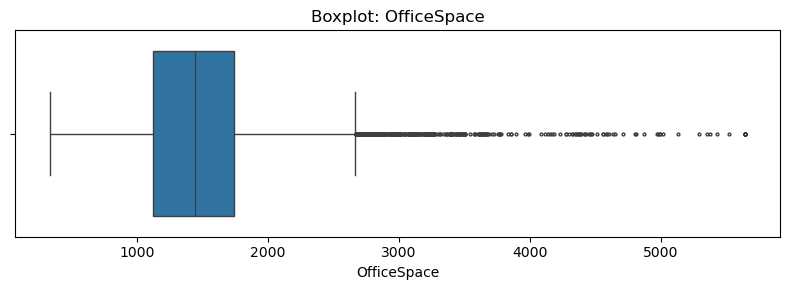

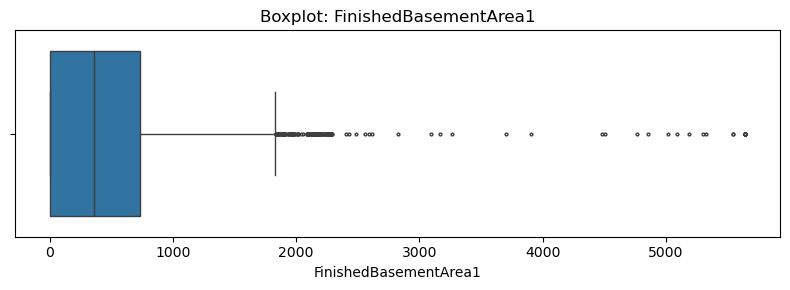

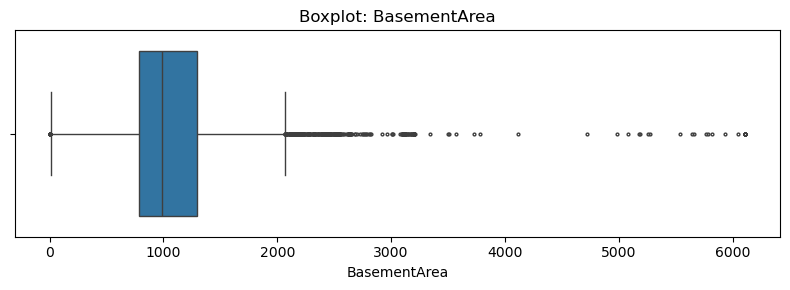

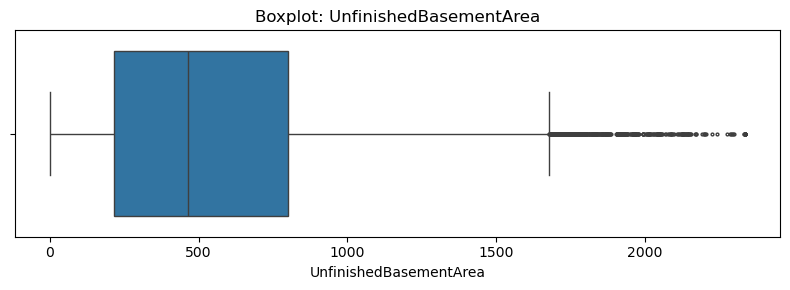

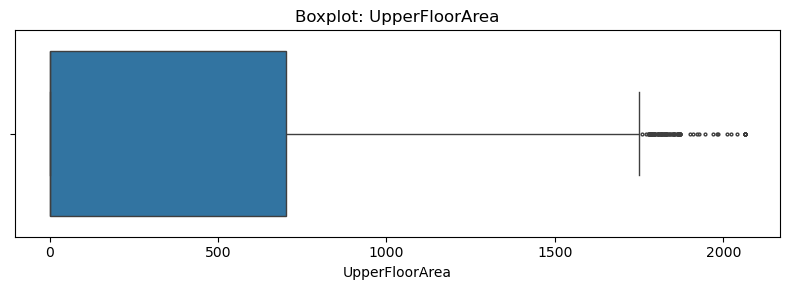

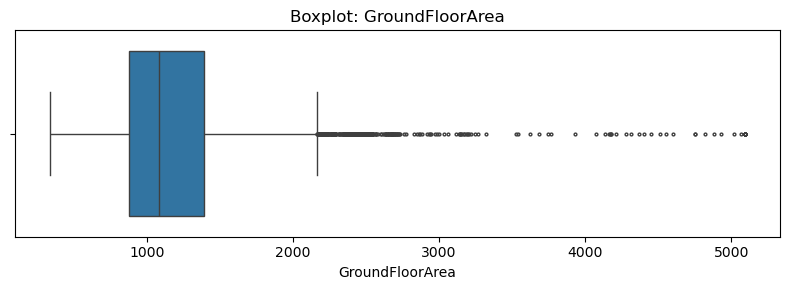

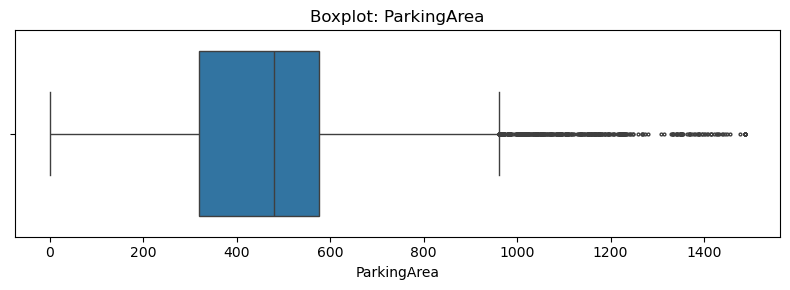

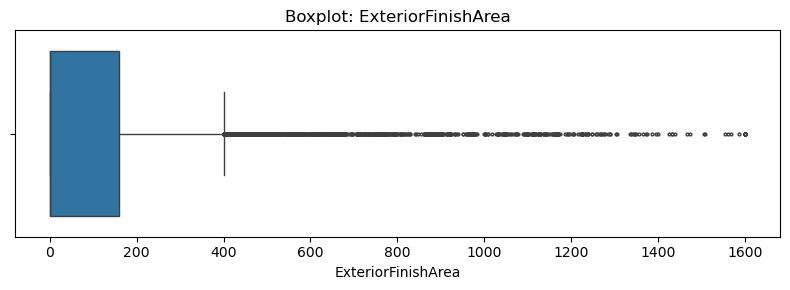

In [30]:
# ============================================================================
# STEP 3B: EXPLORE PREPROCESSED DATA (OUTLIER/ANOMALY CHECKS)
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Helper to iterate n plots at a time
def chunked(seq, size=4):
    for i in range(0, len(seq), size):
        yield seq[i:i+size]

numeric_cols = X_processed.select_dtypes(include=[np.number]).columns
orig_categorical = X.select_dtypes(include=['object']).columns
numeric_non_cat = [c for c in numeric_cols if c not in orig_categorical]

# Dedicated view for PlotSize if present
plot_col = next((c for c in numeric_cols if c.lower() == 'plotsize'), None)
if plot_col:
    plt.figure(figsize=(6, 4))
    plt.hist(X_processed[plot_col], bins=30, color='darkorange', edgecolor='white')
    plt.yscale('log')
    plt.title(f'Distribution: {plot_col}')
    plt.xlabel(plot_col)
    plt.tight_layout()
    plt.show()
else:
    similar = [c for c in numeric_cols if 'plot' in c.lower()]
    print("Note: 'PlotSize' column not found; similar columns:", similar)

# # Numeric distributions in batches of 4 (2x2 grid per figure)
# for batch in chunked(list(numeric_cols), 4):
#     rows = 2; cols = 2
#     fig, axes = plt.subplots(rows, cols, figsize=(12, 8))
#     axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
#     for ax, col in zip(axes, batch):
#         ax.hist(X_processed[col], bins=30, color='steelblue', edgecolor='white')
#         ax.set_yscale('log')
#         ax.set_title(f'Distribution: {col}')
#         ax.set_xlabel(col)
#     # hide any unused subplots
#     for ax in axes[len(batch):]:
#         ax.axis('off')
#     plt.tight_layout()
#     plt.show()

# Class balance bar chart
class_counts = y.value_counts().sort_index()
plt.figure(figsize=(6, 4))
class_counts.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Class balance (OfficeCategory)')
plt.xlabel('OfficeCategory')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
for i, v in enumerate(class_counts):
    plt.text(i, v, f"{v}", ha='center', va='bottom', fontsize=8)
plt.show()

# Correlation heatmap for top-variance numeric features (annotated)
var_cols = X_processed[numeric_non_cat].var().sort_values(ascending=False)
top_corr_cols = var_cols.head(20).index  # cap to keep heatmap readable
plt.figure(figsize=(14, 10))
corr = X_processed[top_corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, square=True)
plt.title('Correlation Heatmap (Top-variance Numeric Features)')
plt.tight_layout()
plt.show()

# Scatter plots for strong correlations (|r| > 0.5)
strong_pairs = []
abs_corr = corr.abs()
cols = list(corr.columns)
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        if abs_corr.iloc[i, j] > 0.3:
            strong_pairs.append((cols[i], cols[j], corr.iloc[i, j]))
if not strong_pairs:
    print('No strong correlation pairs above threshold.')
else:
    max_pairs = 12
    for c1, c2, r in strong_pairs[:max_pairs]:
        plt.figure(figsize=(6, 4))
        sns.scatterplot(x=X_processed[c1], y=X_processed[c2], alpha=0.5, s=15)
        plt.title(f'{c1} vs {c2} (corr={r:.2f})')
        plt.xlabel(c1)
        plt.ylabel(c2)
        plt.tight_layout()
        plt.show()

# Boxplots on high-variance features to spot outliers
sample_cols = var_cols.head(10).index
for col in sample_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=X_processed[col], orient='h', fliersize=2)
    plt.title(f'Boxplot: {col}')
    plt.tight_layout()
    plt.show()

# Bar plots of categorical frequencies (disabled)
# for col in orig_categorical:
#     plt.figure(figsize=(8, 3))
#     X[col].value_counts().head(20).plot(kind='bar')
#     plt.title(f'Top categories for {col}')
#     plt.tight_layout()
#     plt.show()


In [6]:
# ============================================================================
# STEP 4: TRAIN-VALIDATION SPLIT
# ============================================================================

X_train, X_val, y_train, y_val = train_test_split(
    X_processed, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTrain set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")


Train set: (28000, 79)
Validation set: (7000, 79)


In [17]:
!pip install lightgbm xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 24.6 MB/s eta 0:00:00


In [1]:
# ============================================================================
# STEP 5: TRAIN BASELINE MODEL (LOGISTIC REGRESSION)
# ============================================================================

# TODO: Try different models!
# - RandomForestClassifier
# - XGBClassifier
# - GradientBoostingClassifier
# - Neural Networks (MLPClassifier)
# - Ensemble methods (VotingClassifier, StackingClassifier)

from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
# Create individual models
model1 = RandomForestClassifier(n_estimators=200, random_state=42)
model2 = XGBClassifier(n_estimators=200, random_state=42)

# Voting ensemble (combines predictions)
ensemble = VotingClassifier(
    estimators=[('rf', model1), ('xgb', model2)],
    voting='soft',  # Average probabilities
    weights=[1, 1.3]  # Slightly favor XGBoost
)
ensemble.fit(X_train, y_train)

NameError: name 'X_train' is not defined

In [21]:
# =================== IMPROVED MODEL: ===================
# (runs locally; no Colab-specific bits)

# If needed (only once), install LightGBM / XGBoost in your environment:


import numpy as np
import pandas as pd
import warnings, random

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
np.random.seed(42); random.seed(42)

# ---------------------------- Robust Feature Engineer ----------------------------
class AutoFeatureEngineer(BaseEstimator, TransformerMixin):
    """
    - Remembers training schema & types
    - Adds: numeric squares + limited pairwise interactions among top-variance numeric cols
    - Adds: categorical frequency encodings
    """
    def __init__(self, top_k_interactions=8, add_squares=True, add_interactions=True, add_cat_freq=True):
        self.top_k_interactions = top_k_interactions
        self.add_squares = add_squares
        self.add_interactions = add_interactions
        self.add_cat_freq = add_cat_freq

    def fit(self, X, y=None):
        X = X.copy()
        self._train_cols_ = X.columns.tolist()
        self._num_cols_ = X.select_dtypes(include=[np.number]).columns.tolist()
        self._cat_cols_ = [c for c in self._train_cols_ if c not in self._num_cols_]

        if self.add_interactions and len(self._num_cols_) > 1:
            variances = X[self._num_cols_].var().sort_values(ascending=False)
            self._top_num_for_inter_ = variances.index[:min(self.top_k_interactions, len(variances))].tolist()
        else:
            self._top_num_for_inter_ = []

        self._cat_freq_maps_ = {}
        if self.add_cat_freq and len(self._cat_cols_) > 0:
            n = len(X)
            for col in self._cat_cols_:
                freq = X[col].astype(str).value_counts(dropna=False) / n
                self._cat_freq_maps_[col] = freq.to_dict()
        return self

    def _align_schema_and_types(self, X):
        # ensure all training columns exist
        for col in self._train_cols_:
            if col not in X.columns:
                X[col] = np.nan
        # coerce to training-time role
        for col in self._num_cols_:
            X[col] = pd.to_numeric(X[col], errors="coerce")
        for col in self._cat_cols_:
            X[col] = X[col].astype(str).fillna("")
        # drop extra columns
        return X[self._train_cols_]

    def transform(self, X):
        X = X.copy()
        X = self._align_schema_and_types(X)

        # numeric squares
        if self.add_squares and len(self._num_cols_) > 0:
            for col in self._num_cols_:
                X[f"{col}__sq"] = X[col] * X[col]

        # limited pairwise interactions
        if self.add_interactions and len(self._top_num_for_inter_) > 1:
            cols = self._top_num_for_inter_
            for i in range(len(cols)):
                for j in range(i+1, len(cols)):
                    c1, c2 = cols[i], cols[j]
                    X[f"{c1}__x__{c2}"] = X[c1] * X[c2]

        # categorical frequency encodings
        if self.add_cat_freq and len(self._cat_cols_) > 0:
            for col in self._cat_cols_:
                fmap = self._cat_freq_maps_.get(col, {})
                X[f"{col}__freq"] = X[col].map(fmap).fillna(0.0)

        return X

# ---------------------------- Split data (deterministic) ----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ---------------------------- Column-wise preprocessing ----------------------------
numeric_pre = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))  # safe with sparse union
])
categorical_pre = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pre, selector(dtype_include=np.number)),
        ("cat", categorical_pre, selector(dtype_include=object)),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ---------------------------- Base models ----------------------------
xgb = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)
lgb = LGBMClassifier(
    objective="multiclass",
    n_jobs=-1,
    random_state=42
)

# Full pipelines (Fit on RAW X; FE + OHE/scaler happens inside)
xgb_pipe = Pipeline([("feat", AutoFeatureEngineer()), ("prep", preprocessor), ("xgb", xgb)])
lgb_pipe = Pipeline([("feat", AutoFeatureEngineer()), ("prep", preprocessor), ("lgb", lgb)])

# ---------------------------- Hyperparameter spaces (balanced & strong) ----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_space = {
    "feat__top_k_interactions": [6, 8, 10],
    "xgb__n_estimators": [400, 600, 900],
    "xgb__max_depth": [6, 8, 10],
    "xgb__learning_rate": [0.03, 0.05, 0.08],
    "xgb__subsample": [0.8, 1.0],
    "xgb__colsample_bytree": [0.8, 1.0],
    "xgb__min_child_weight": [1, 3, 5],
    "xgb__gamma": [0, 0.1]
}

lgb_space = {
    "feat__top_k_interactions": [6, 8, 10],
    "lgb__n_estimators": [500, 800, 1100],
    "lgb__learning_rate": [0.03, 0.05, 0.08],
    "lgb__num_leaves": [31, 63, 95],
    "lgb__min_child_samples": [10, 20, 30],
    "lgb__subsample": [0.8, 1.0],
    "lgb__colsample_bytree": [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    xgb_pipe, xgb_space, n_iter=25, cv=cv, n_jobs=-1,
    scoring="accuracy", random_state=42, verbose=1
)
lgb_search = RandomizedSearchCV(
    lgb_pipe, lgb_space, n_iter=25, cv=cv, n_jobs=-1,
    scoring="accuracy", random_state=42, verbose=1
)

print("Tuning XGBoost...")
xgb_search.fit(X_train, y_train)
print("Best XGB:", xgb_search.best_params_, "CV:", f"{xgb_search.best_score_:.5f}")

print("\nTuning LightGBM...")
lgb_search.fit(X_train, y_train)
print("Best LGBM:", lgb_search.best_params_, "CV:", f"{lgb_search.best_score_:.5f}")

best_xgb = xgb_search.best_estimator_
best_lgb = lgb_search.best_estimator_

# ---------------------------- Weighted soft vote (based on CV scores) ----------------------------
from sklearn.ensemble import VotingClassifier
w_xgb = xgb_search.best_score_
w_lgb = lgb_search.best_score_
# give a tiny nudge to the stronger one
if w_xgb > w_lgb: w_xgb *= 1.10
else:             w_lgb *= 1.10

voter = VotingClassifier(
    estimators=[("xgb", best_xgb), ("lgb", best_lgb)],
    voting="soft",
    weights=[w_xgb, w_lgb],
    n_jobs=-1
)
voter.fit(X_train, y_train)

# ---------------------------- Validation ----------------------------
val_pred = voter.predict(X_val)
val_acc = accuracy_score(y_val, val_pred)
print(f"\nValidation Accuracy (Weighted XGB+LGB): {val_acc:.5f}")
print("\nClassification Report (Validation):")
print(classification_report(y_val, val_pred))

ConfusionMatrixDisplay.from_predictions(y_val, val_pred)
plt.title("Validation Confusion Matrix — Weighted XGB + LGBM")
plt.show()

# ---------------------------- Predict test & save submission ----------------------------
# (works on RAW test — FE & preprocessing are inside the pipelines)
test = pd.read_csv("office_test.csv")
test_pred = voter.predict(test)

submission = pd.DataFrame({"Id": range(len(test_pred)), "OfficeCategory": test_pred})
submission.to_csv("submission.csv", index=False)
print("\n✅ Saved submission.csv")



Tuning XGBoost...
Fitting 5 folds for each of 25 candidates, totalling 125 fits


Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 281, in main
    registry[rtype][name] -= 1
    ~~~~~~~~~~~~~~~^^^^^^
KeyError: '/var/folders/_0/2q6tdnws4sz0qwbqyc2761740000gp/T/joblib_memmapping_folder_95653_171a223a7e774910b913900e1def274a_aacdd1874aa840cbafa9a734d9579b5d/95653-13411904128-70ff66bffbf640029b0f3e5455b88e6e.pkl'
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 281, in main
    registry[rtype][name] -= 1
    ~~~~~~~~~~~~~~~^^^^^^
KeyError: '/var/folders/_0/2q6tdnws4sz0qwbqyc2761740000gp/T/joblib_memmapping_folder_95653_171a223a7e774910b913900e1def274a_aacdd1874aa840cbafa9a734d9579b5d/95653-13411904128-40449926ba3b46ad88e9f074d660a2d8.pkl'
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 28

KeyboardInterrupt: 

In [21]:
%pip install catboost

Note: you may need to restart the kernel to use updated packages.


In [22]:
# ===================== CatBoost + Probability Blending (full cell) =====================
# If you don't have CatBoost yet, run in a separate cell once:  %pip install catboost

import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

# 0) Identify columns from your original training frame X
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

def to_catboost_df(df_base: pd.DataFrame) -> pd.DataFrame:
    """Make a CatBoost-friendly copy:
       - same columns/order as X
       - numerics coerced to numeric (NaN allowed)
       - categoricals cast to string with 'Missing' for NaN
    """
    df = df_base.copy()
    df = df.reindex(columns=X.columns, fill_value=np.nan)

    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    for c in cat_cols:
        df[c] = df[c].astype("object").fillna("Missing").astype(str)

    return df

# 1) Prepare CatBoost-friendly train/val
X_train_cb = to_catboost_df(X_train)
X_val_cb   = to_catboost_df(X_val)
cat_idx    = [X.columns.get_loc(c) for c in cat_cols]  # indices of categorical features

# 2) Train CatBoost (handles categoricals natively) with early stopping
cat = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="MultiClass",
    iterations=2000,          # high cap; will stop earlier via od_wait
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3.0,
    random_seed=42,
    od_type="Iter",           # early stopping
    od_wait=50,               # patience
    verbose=False,
    allow_writing_files=False
)

cat.fit(
    X_train_cb, y_train,
    cat_features=cat_idx,
    eval_set=(X_val_cb, y_val),
    verbose=False
)

# 3) Validate CatBoost alone
proba_cat_val = cat.predict_proba(X_val_cb)
pred_cat_val  = np.argmax(proba_cat_val, axis=1)
acc_cat = accuracy_score(y_val, pred_cat_val)
print(f"CatBoost Validation Accuracy: {acc_cat:.5f}")

# 4) Blend CatBoost with your existing ensemble `voter` (soft probs)
#    (Assumes `voter` is already fitted on X_train/y_train)
proba_voter_val = voter.predict_proba(X_val)  # voter pipeline handles raw X_val

best_w, best_acc = None, -1.0
for w in np.linspace(0.20, 0.80, 13):  # 0.20, 0.25, ..., 0.80
    blend_val = w * proba_cat_val + (1 - w) * proba_voter_val
    pred_val  = np.argmax(blend_val, axis=1)
    acc       = accuracy_score(y_val, pred_val)
    if acc > best_acc:
        best_acc, best_w = acc, float(w)

print(f"Best blend weight (CatBoost share): {best_w:.2f} | Blended Val Accuracy: {best_acc:.5f}")

# 5) Make TEST predictions with the same blend and save submission
test = pd.read_csv("office_test.csv")

# CatBoost view of test
test_cb = to_catboost_df(test)
proba_cat_test = cat.predict_proba(test_cb)

# Voter view of test (ensure same columns/order; pipeline will handle types)
test_for_voter = test.reindex(columns=X.columns, fill_value=np.nan)
proba_voter_test = voter.predict_proba(test_for_voter)

# Blend and save
proba_blend_test = best_w * proba_cat_test + (1 - best_w) * proba_voter_test
pred_test        = np.argmax(proba_blend_test, axis=1)

pd.DataFrame({"Id": range(len(pred_test)), "OfficeCategory": pred_test}).to_csv("submission.csv", index=False)
print("✅ Saved submission.csv (CatBoost + voter blended)")


CatBoost Validation Accuracy: 0.85814
Best blend weight (CatBoost share): 0.65 | Blended Val Accuracy: 0.86371
✅ Saved submission.csv (CatBoost + voter blended)


In [23]:
%pip install catboost

Note: you may need to restart the kernel to use updated packages.


In [24]:
# ===================== Stacking: CatBoost + Voter -> Logistic Meta-learner =====================
# One-time install if needed (run in another cell/terminal):  %pip install catboost

import numpy as np, pandas as pd, time
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# ----- CatBoost-friendly copies (fix NaN in categoricals) -----
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

def to_catboost_df(df_base: pd.DataFrame) -> pd.DataFrame:
    df = df_base.copy()
    df = df.reindex(columns=X.columns, fill_value=np.nan)
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    for c in cat_cols:
        df[c] = df[c].astype("object").fillna("Missing").astype(str)
    return df

X_train_cb = to_catboost_df(X_train)
X_val_cb   = to_catboost_df(X_val)
cat_idx    = [X.columns.get_loc(c) for c in cat_cols]

# ----- Train a strong but fast CatBoost (early stopping + all cores) -----
cat = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="MultiClass",
    iterations=1200,          # high cap; early stopping will stop earlier
    learning_rate=0.06,
    depth=6,
    l2_leaf_reg=3.0,
    bootstrap_type="Bernoulli",
    subsample=0.8,
    rsm=0.8,
    random_seed=42,
    od_type="Iter",
    od_wait=50,
    thread_count=-1,
    verbose=False,
    allow_writing_files=False
)

t0 = time.time()
cat.fit(X_train_cb, y_train, cat_features=cat_idx, eval_set=(X_val_cb, y_val), verbose=False)
print("CatBoost best_iter:", cat.get_best_iteration(), "| fit secs:", round(time.time()-t0, 1))

# ----- Get validation probabilities from both models -----
proba_cat_val   = cat.predict_proba(X_val_cb)
proba_voter_val = voter.predict_proba(X_val)  # voter handles raw X_val

# Build meta-features = concat probabilities (shape: n_val x (K+K))
K = proba_cat_val.shape[1]
X_meta_val = np.hstack([proba_cat_val, proba_voter_val])

# Optional: hold out part of val for a cleaner meta estimate, then refit on full val
X_meta_tr, X_meta_ho, y_meta_tr, y_meta_ho = train_test_split(
    X_meta_val, y_val, test_size=0.25, stratify=y_val, random_state=42
)

meta = LogisticRegression(max_iter=2000, multi_class="multinomial", n_jobs=-1)
meta.fit(X_meta_tr, y_meta_tr)
ho_pred = meta.predict(X_meta_ho)
print("Meta holdout accuracy:", f"{accuracy_score(y_meta_ho, ho_pred):.5f}")

# Refit meta on full val meta-features (to use all info for test-time)
meta.fit(X_meta_val, y_val)

# ----- Predict TEST with the stacked model -----
test = pd.read_csv("office_test.csv")
test_cb = to_catboost_df(test)
proba_cat_test   = cat.predict_proba(test_cb)

test_for_voter   = test.reindex(columns=X.columns, fill_value=np.nan)
proba_voter_test = voter.predict_proba(test_for_voter)

X_meta_test = np.hstack([proba_cat_test, proba_voter_test])
pred_test   = np.argmax(meta.predict_proba(X_meta_test), axis=1)

pd.DataFrame({"Id": range(len(pred_test)), "OfficeCategory": pred_test}).to_csv("submission.csv", index=False)
print("✅ Saved submission.csv (Stacked CatBoost + Voter via Logistic meta-learner)")


CatBoost best_iter: 1196 | fit secs: 178.8
Meta holdout accuracy: 0.88057
✅ Saved submission.csv (Stacked CatBoost + Voter via Logistic meta-learner)


In [26]:
# ===================== OOF Stacking: CatBoost + XGB + RF -> Logistic meta-learner =====================
# One-time installs (run separately if needed):
# %pip install catboost xgboost

import numpy as np, pandas as pd, time, warnings, random
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
np.random.seed(42); random.seed(42)

# ---- Helper: robust feature engineering for tree models that use OHE
class AutoFeatureEngineer:
    """Lightweight FE: numeric squares + limited interactions + categorical freq encodings."""
    def __init__(self, top_k_interactions=8, add_squares=True, add_interactions=True, add_cat_freq=True):
        self.top_k_interactions = top_k_interactions
        self.add_squares = add_squares
        self.add_interactions = add_interactions
        self.add_cat_freq = add_cat_freq
        self._fitted = False

    def fit(self, X):
        X = X.copy()
        self.train_cols_ = X.columns.tolist()
        self.num_cols_ = X.select_dtypes(include=[np.number]).columns.tolist()
        self.cat_cols_ = [c for c in self.train_cols_ if c not in self.num_cols_]
        # pick top variance num cols for interactions
        if self.add_interactions and len(self.num_cols_) > 1:
            variances = X[self.num_cols_].var().sort_values(ascending=False)
            self.top_inter_ = variances.index[:min(self.top_k_interactions, len(variances))].tolist()
        else:
            self.top_inter_ = []
        # frequency maps for categoricals
        self.cat_freq_ = {}
        if self.add_cat_freq_ and len(self.cat_cols_) > 0:
            n = len(X)
            for c in self.cat_cols_:
                freq = X[c].astype(str).value_counts(dropna=False) / n
                self.cat_freq_[c] = freq.to_dict()
        self._fitted = True
        return self

    # small typo fix: property convenience
    @property
    def add_cat_freq_(self):
        return self.add_cat_freq

    def _align(self, X):
        for col in self.train_cols_:
            if col not in X.columns:
                X[col] = np.nan
        # numeric as numeric, categorical as string (not NaN)
        for c in self.num_cols_:
            X[c] = pd.to_numeric(X[c], errors="coerce")
        for c in self.cat_cols_:
            X[c] = X[c].astype("object").fillna("Missing").astype(str)
        return X[self.train_cols_]

    def transform(self, X):
        assert self._fitted, "Call fit() first"
        X = self._align(X.copy())
        # squares
        if self.add_squares:
            for c in self.num_cols_:
                X[f"{c}__sq"] = X[c] * X[c]
        # pairwise interactions
        if self.add_interactions and len(self.top_inter_) > 1:
            cols = self.top_inter_
            for i in range(len(cols)):
                for j in range(i+1, len(cols)):
                    c1, c2 = cols[i], cols[j]
                    X[f"{c1}__x__{c2}"] = X[c1] * X[c2]
        # categorical frequency encodings
        if self.add_cat_freq_ and len(self.cat_cols_) > 0:
            for c in self.cat_cols_:
                fmap = self.cat_freq_.get(c, {})
                X[f"{c}__freq"] = X[c].map(fmap).fillna(0.0)
        return X

# ---- CatBoost wants categoricals as strings, NaN -> "Missing"
def to_catboost_df(df_base: pd.DataFrame, X_ref: pd.DataFrame):
    cat_cols = X_ref.select_dtypes(include="object").columns.tolist()
    num_cols = [c for c in X_ref.columns if c not in cat_cols]
    df = df_base.copy()
    df = df.reindex(columns=X_ref.columns, fill_value=np.nan)
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    for c in cat_cols:
        df[c] = df[c].astype("object").fillna("Missing").astype(str)
    cat_idx = [df.columns.get_loc(c) for c in cat_cols]
    return df, cat_idx

# ---- Preprocessor for XGB/RF pipelines
numeric_pre = Pipeline([("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler(with_mean=False))])
categorical_pre = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                            ("ohe", OneHotEncoder(handle_unknown="ignore"))])
preprocessor = ColumnTransformer(
    [("num", numeric_pre, selector(dtype_include=np.number)),
     ("cat", categorical_pre, selector(dtype_include=object))],
    remainder="drop", verbose_feature_names_out=False
)

# ---- Strong default base models (you can swap to your tuned params if you want)
def make_xgb():
    return XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        tree_method="hist",
        n_estimators=700,       # fixed budget (no early stopping)
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        gamma=0.0,
        n_jobs=1,               # avoid nested parallelism; CV runs outside
        random_state=42
    )

def make_rf():
    return RandomForestClassifier(
        n_estimators=900,
        max_depth=24,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        bootstrap=True,
        n_jobs=1,               # avoid nested parallelism
        random_state=42
    )

# ---- Build full pipelines for XGB / RF (FE + preprocess + model)
def make_xgb_pipe(X_sample):
    fe = AutoFeatureEngineer(top_k_interactions=8, add_squares=True, add_interactions=True, add_cat_freq=True)
    fe.fit(X_sample)
    return fe, Pipeline([("prep", preprocessor), ("xgb", make_xgb())])

def make_rf_pipe(X_sample):
    fe = AutoFeatureEngineer(top_k_interactions=8, add_squares=True, add_interactions=True, add_cat_freq=True)
    fe.fit(X_sample)
    return fe, Pipeline([("prep", preprocessor), ("rf", make_rf())])

# ================= OOF loop =================
K = len(np.unique(y))
n = len(X)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_cat = np.zeros((n, K))
oof_xgb = np.zeros((n, K))
oof_rf  = np.zeros((n, K))

# Test probs averaged across folds
test = pd.read_csv("office_test.csv")
test_cat_sum = np.zeros((len(test), K))
test_xgb_sum = np.zeros((len(test), K))
test_rf_sum  = np.zeros((len(test), K))

fold_acc = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n===== Fold {fold}/{skf.n_splits} =====")
    X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
    X_va, y_va = X.iloc[va_idx], y.iloc[va_idx]

    # --- CatBoost (handles categoricals natively)
    X_tr_cb, cat_idx = to_catboost_df(X_tr, X)
    X_va_cb, _       = to_catboost_df(X_va, X)
    test_cb, _       = to_catboost_df(test, X)

    cat = CatBoostClassifier(
        loss_function="MultiClass",
        eval_metric="MultiClass",
        iterations=1200,
        learning_rate=0.06,
        depth=6,
        l2_leaf_reg=3.0,
        bootstrap_type="Bernoulli",
        subsample=0.8,
        rsm=0.8,
        random_seed=42 + fold,
        od_type="Iter",
        od_wait=50,
        thread_count=-1,
        verbose=False,
        allow_writing_files=False
    )
    cat.fit(X_tr_cb, y_tr, cat_features=cat_idx, eval_set=(X_va_cb, y_va), verbose=False)
    proba_cat_va = cat.predict_proba(X_va_cb)
    oof_cat[va_idx] = proba_cat_va
    test_cat_sum += cat.predict_proba(test_cb)

    # --- XGB pipeline (NO early stopping; fixed n_estimators)
    fe_xgb, xgb_pipe = make_xgb_pipe(X_tr)
    X_tr_x = fe_xgb.transform(X_tr)
    X_va_x = fe_xgb.transform(X_va)
    test_x = fe_xgb.transform(test.reindex(columns=X.columns, fill_value=np.nan))

    xgb_pipe.fit(X_tr_x, y_tr)  # simple fit; no eval_set / early stopping kwargs
    proba_xgb_va = xgb_pipe.predict_proba(X_va_x)
    oof_xgb[va_idx] = proba_xgb_va
    test_xgb_sum += xgb_pipe.predict_proba(test_x)

    # --- RF pipeline
    fe_rf, rf_pipe = make_rf_pipe(X_tr)
    X_tr_r = fe_rf.transform(X_tr)
    X_va_r = fe_rf.transform(X_va)
    test_r = fe_rf.transform(test.reindex(columns=X.columns, fill_value=np.nan))

    rf_pipe.fit(X_tr_r, y_tr)
    proba_rf_va = rf_pipe.predict_proba(X_va_r)
    oof_rf[va_idx] = proba_rf_va
    test_rf_sum += rf_pipe.predict_proba(test_r)

    # quick fold score of simple average (sanity)
    avg_va = (proba_cat_va + proba_xgb_va + proba_rf_va) / 3.0
    fold_acc.append(accuracy_score(y_va, np.argmax(avg_va, axis=1)))
    print(f"Fold {fold} done. Simple-avg fold acc: {fold_acc[-1]:.5f}")

print("Mean simple-avg CV acc:", np.mean(fold_acc).round(5))

# ----- Meta features (OOF)
X_meta = np.hstack([oof_cat, oof_xgb, oof_rf])  # shape: (n, 3*K)

# Optional: check meta CV to gauge lift
meta = LogisticRegression(max_iter=4000, multi_class="multinomial")  # removed n_jobs for broad compat
cv_scores = cross_val_score(meta, X_meta, y, cv=skf, scoring="accuracy", n_jobs=-1)
print("Meta CV acc (OOF):", f"{cv_scores.mean():.5f} +/- {cv_scores.std():.5f}")

# Fit meta on full OOF features
meta.fit(X_meta, y)

# ----- Prepare meta TEST features (avg across folds)
proba_cat_test = test_cat_sum / skf.n_splits
proba_xgb_test = test_xgb_sum / skf.n_splits
proba_rf_test  = test_rf_sum / skf.n_splits
X_meta_test = np.hstack([proba_cat_test, proba_xgb_test, proba_rf_test])

# Final TEST prediction via meta
pred_test = np.argmax(meta.predict_proba(X_meta_test), axis=1)
pd.DataFrame({"Id": range(len(pred_test)), "OfficeCategory": pred_test}).to_csv("submission.csv", index=False)
print("✅ Saved submission.csv (OOF Stacking: CatBoost + XGB + RF -> Logistic)")



===== Fold 1/5 =====
Fold 1 done. Simple-avg fold acc: 0.85257

===== Fold 2/5 =====
Fold 2 done. Simple-avg fold acc: 0.84786

===== Fold 3/5 =====
Fold 3 done. Simple-avg fold acc: 0.85857

===== Fold 4/5 =====
Fold 4 done. Simple-avg fold acc: 0.85014

===== Fold 5/5 =====
Fold 5 done. Simple-avg fold acc: 0.84771
Mean simple-avg CV acc: 0.85137


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in ve

Meta CV acc (OOF): 0.86777 +/- 0.00380
✅ Saved submission.csv (OOF Stacking: CatBoost + XGB + RF -> Logistic)


In [12]:
# 1) Load test
test = pd.read_csv("office_test.csv")

# 2) Build a test set processed the SAME WAY as training
#    (fit imputers/label encoders on training X, then transform test)
_, test_processed = simple_preprocess(X, test)

# 3) Predict on the processed test
test_pred = voter.predict(test_processed)

# 4) Save
submission = pd.DataFrame({"Id": range(len(test_pred)),
                           "OfficeCategory": test_pred})
submission.to_csv("submission.csv", index=False)
print("✅ Predictions saved to submission.csv")


Numeric features: 37
Categorical features: 42
✅ Predictions saved to submission.csv


In [ ]:
try:
    test = pd.read_csv('office_test.csv')
    test_pred = voter.predict(test)
    submission = pd.DataFrame({"Id": range(len(test_pred)), "OfficeCategory": test_pred})
    submission.to_csv("submission.csv", index=False)
    print("\nSaved submission.csv")
except NameError:
    print("\nNo `test` DataFrame found — skipping submission. (Load it as in your STEP 7 and rerun.)")


In [10]:
# ============================================================================
# STEP 6: EVALUATE MODEL
# ============================================================================

# Predictions
y_train_pred = ensemble.predict(X_train)
y_val_pred = ensemble.predict(X_val)

# Calculate accuracy
train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)

print(f"\nTrain Accuracy: {train_acc*100:.2f}%")
print(f"Validation Accuracy: {val_acc*100:.2f}%")

# Detailed classification report
print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred))

# TODO: Add more evaluation metrics
# - Confusion matrix
# - Per-class accuracy
# - Cross-validation scores
# - Feature importance (for tree models)

NameError: name 'ensemble' is not defined

In [11]:
# ============================================================================
# STEP 7: MAKE PREDICTIONS ON TEST SET (OPTIONAL)
# ============================================================================

# Upload this file on Kaggle

# Load test data
test = pd.read_csv('office_test.csv')

# Preprocess test data (use same preprocessing as training)
X_test_processed = simple_preprocess(X, test)[1]


# Make predictions
test_predictions = model.predict(X_test_processed)

# Save predictions
submission = pd.DataFrame({
    'Id': range(len(test_predictions)),
    'OfficeCategory': test_predictions
})
submission.to_csv('submission.csv', index=False)

print("Predictions saved to submission.csv")

Numeric features: 37
Categorical features: 42


NameError: name 'model' is not defined

# 🎯 IDEAS TO TRY - IMPROVE YOUR MODEL!

## 1. 🔧 Feature Engineering

Create new features that capture relationships between variables:

```python
# Interaction features (Quality × Size effect)
X['Quality_Size'] = X['BuildingGrade'] * X['OfficeSpace']

# Polynomial features (Non-linear relationships)
X['OfficeSpace_squared'] = X['OfficeSpace'] ** 2
X['BuildingGrade_squared'] = X['BuildingGrade'] ** 2

# Ratio features (Relative measurements)
X['Space_Plot_Ratio'] = X['OfficeSpace'] / (X['PlotSize'] + 1)
X['Restroom_Meeting_Ratio'] = X['Restrooms'] / (X['MeetingRooms'] + 1)

# Aggregated features
X['TotalArea'] = X['OfficeSpace'] + X['BasementArea'] + X['ParkingArea']
```

---

## 2. 🌲 Different Models

Try tree-based models (often better than linear models for this type of data):

```python
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Random Forest
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# XGBoost (usually best for tabular data)
model = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    random_state=42
)
model.fit(X_train, y_train)
```

---

## 3. 🎛️ Hyperparameter Tuning

Optimize your model's parameters:

```python
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, 25],
    'min_samples_split': [5, 10, 20]
}

# Grid search with cross-validation
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid.fit(X_train, y_train)

# Best parameters
print(f"Best parameters: {grid.best_params_}")
print(f"Best CV score: {grid.best_score_:.4f}")
```

---

## 4. 🤝 Ensemble Methods

Combine multiple models for better predictions:

```python
from sklearn.ensemble import VotingClassifier

# Create individual models
model1 = RandomForestClassifier(n_estimators=200, random_state=42)
model2 = XGBClassifier(n_estimators=200, random_state=42)

# Voting ensemble (combines predictions)
ensemble = VotingClassifier(
    estimators=[('rf', model1), ('xgb', model2)],
    voting='soft',  # Average probabilities
    weights=[1, 1.2]  # Slightly favor XGBoost
)
ensemble.fit(X_train, y_train)
```

---

## 5. 🎯 Feature Selection

Select only the most important features:

```python
from sklearn.feature_selection import SelectKBest, f_classif

# Select top 50 features
selector = SelectKBest(f_classif, k=50)
X_train_selected = selector.fit_transform(X_train, y_train)
X_val_selected = selector.transform(X_val)

# Get selected feature names
selected_features = X_train.columns[selector.get_support()]
print(f"Selected features: {list(selected_features)}")
```

---

## 6. 📈 Cross-Validation

Get more reliable performance estimates:

```python
from sklearn.model_selection import cross_val_score

# 5-fold cross-validation
scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print(f"CV Accuracy: {scores.mean():.4f} (±{scores.std():.4f})")
```